# Notebook 04 — Permeability Prediction Model
**AGD 2026 | AI Workflow Engineer**

Goal: Build depth-resolved permeability profiles for all wells.
Calibrate XGBoost against ThermoGIS point estimates.
Generate SHAP feature importance plots.

In [1]:
import sys, warnings, yaml
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from pathlib import Path

with open("../config/settings.yaml") as f:
    CFG = yaml.safe_load(f)

INTER_DIR  = Path("..") / CFG["paths"]["data"]["interim"]
PROC_DIR   = Path("..") / CFG["paths"]["data"]["processed"]
EXTERNAL   = Path("..") / CFG["paths"]["data"]["external"]
MODEL_DIR  = Path("..") / CFG["paths"]["outputs"]["models"]
FIG_DIR    = Path("..") / CFG["paths"]["outputs"]["figures"]
MODEL_DIR.mkdir(parents=True, exist_ok=True)

from src.models.permeability import PermeabilityModel, compute_neutron_density_porosity


## 1. Load imputed dataset

In [2]:
df = pd.read_csv(INTER_DIR / "all_wells_imputed.csv")
print(f"Loaded: {df.shape}")
print(f"Rotliegend rows: {df['is_rotliegend'].sum():,}")


Loaded: (99379, 30)
Rotliegend rows: 10,503


## 2. Load ThermoGIS data (calibration anchor)

In [3]:
thermo_raw = pd.read_excel(EXTERNAL / "ThermoGIS Data.xlsx", sheet_name=None)
print(f"ThermoGIS sheets: {list(thermo_raw.keys())}")

# Use first sheet or the one with permeability data
thermo_df = None
for sheet_name, sheet_df in thermo_raw.items():
    cols_upper = [c.upper() for c in sheet_df.columns]
    if any("PERM" in c or "_K_" in c or "PERMEAB" in c for c in cols_upper):
        thermo_df = sheet_df.copy()
        thermo_df.columns = [c.strip().upper().replace(" ","_") for c in thermo_df.columns]
        print(f"Using sheet: {sheet_name}")
        print(f"Columns: {list(thermo_df.columns)}")
        break

if thermo_df is None:
    # Load all sheets and combine
    frames = []
    for sheet_name, sheet_df in thermo_raw.items():
        sheet_df.columns = [c.strip().upper().replace(" ","_") for c in sheet_df.columns]
        frames.append(sheet_df)
    thermo_df = pd.concat(frames, ignore_index=True)
    print("Combined all sheets:", thermo_df.shape)

print("\nThermoGIS data head:")
print(thermo_df.head().to_string())


ThermoGIS sheets: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']


Combined all sheets: (56, 7)

ThermoGIS data head:
      WELL_NAME     PKP-01 UNNAMED:_2 UNNAMED:_3 UNNAMED:_4 EVD-01 JUT-01
0             x  141577.55        NaN        NaN        NaN    NaN    NaN
1             Y  456881.76        NaN        NaN        NaN    NaN    NaN
2           NaN        NaN        NaN        NaN        NaN    NaN    NaN
3      Property       Unit        P90        P50        P10    NaN    NaN
4  Permeability         mD         13         82        521    NaN    NaN


## 3. Fit permeability model

In [4]:
perm_model = PermeabilityModel(
    n_estimators=CFG["models"]["xgboost"]["n_estimators"],
    max_depth=CFG["models"]["xgboost"]["max_depth"],
    learning_rate=CFG["models"]["xgboost"]["learning_rate"]
)

perm_model.fit(df, thermo_df)
print(f"\nModel metrics: {perm_model.metrics}")



Fitting PermeabilityModel...
  [BLT-01] Using Kozeny-Carman fallback for 2611 rows
  [EVD-01] Using Kozeny-Carman fallback for 4090 rows
  [JUT-01] Using Kozeny-Carman fallback for 1597 rows
  [PKP-01] Using Kozeny-Carman fallback for 2205 rows
  Training samples: 5,727 from wells: ['BLT-01', 'EVD-01', 'PKP-01']


  Trained Q10 model


  Trained Q50 model


  Trained Q90 model


  SHAP values computed


  LOWO OOF — MAE(log10 k): 0.045, R²: 0.971

Model metrics: {'mae_log10': 0.045, 'r2': 0.971, 'n_train': 5727}


## 4. Generate depth-resolved permeability profiles

In [5]:
df_with_perm = perm_model.predict_profiles(df)

# Check output
perm_cols = ["k_p10_md", "k_p50_md", "k_p90_md", "k_kc_md"]
rotl = df_with_perm[df_with_perm["is_rotliegend"]]
print("Rotliegend permeability summary:")
print(rotl.groupby("WELL_ID")[perm_cols].mean().round(2).to_string())


Permeability profiles generated for 4 wells
Rotliegend permeability summary:
         k_p10_md  k_p50_md  k_p90_md  k_kc_md
WELL_ID                                       
BLT-01     559.07    752.10    780.86   741.18
EVD-01     205.08    519.12    535.28   523.81
JUT-01        NaN       NaN       NaN      NaN
PKP-01     190.21    367.95    384.85   373.96


## 5. Well summary vs ThermoGIS

In [6]:
well_summary = perm_model.get_well_summary(df_with_perm)
print("\nML permeability estimates per well (Rotliegend mean):")
print(well_summary.to_string())

print("\nCompare with ThermoGIS — look for reasonable agreement:")
print("(ThermoGIS P50 values are used as calibration anchors)")



ML permeability estimates per well (Rotliegend mean):
         k_p10_md  k_p50_md  k_p90_md  phit_mean  n_samples
WELL_ID                                                    
BLT-01     559.07    752.10    780.86       0.14       2611
EVD-01     205.08    519.12    535.28       0.11       4090
JUT-01        NaN       NaN       NaN        NaN       1597
PKP-01     190.21    367.95    384.85       0.10       2205

Compare with ThermoGIS — look for reasonable agreement:
(ThermoGIS P50 values are used as calibration anchors)


## 6. Permeability depth profiles — plot

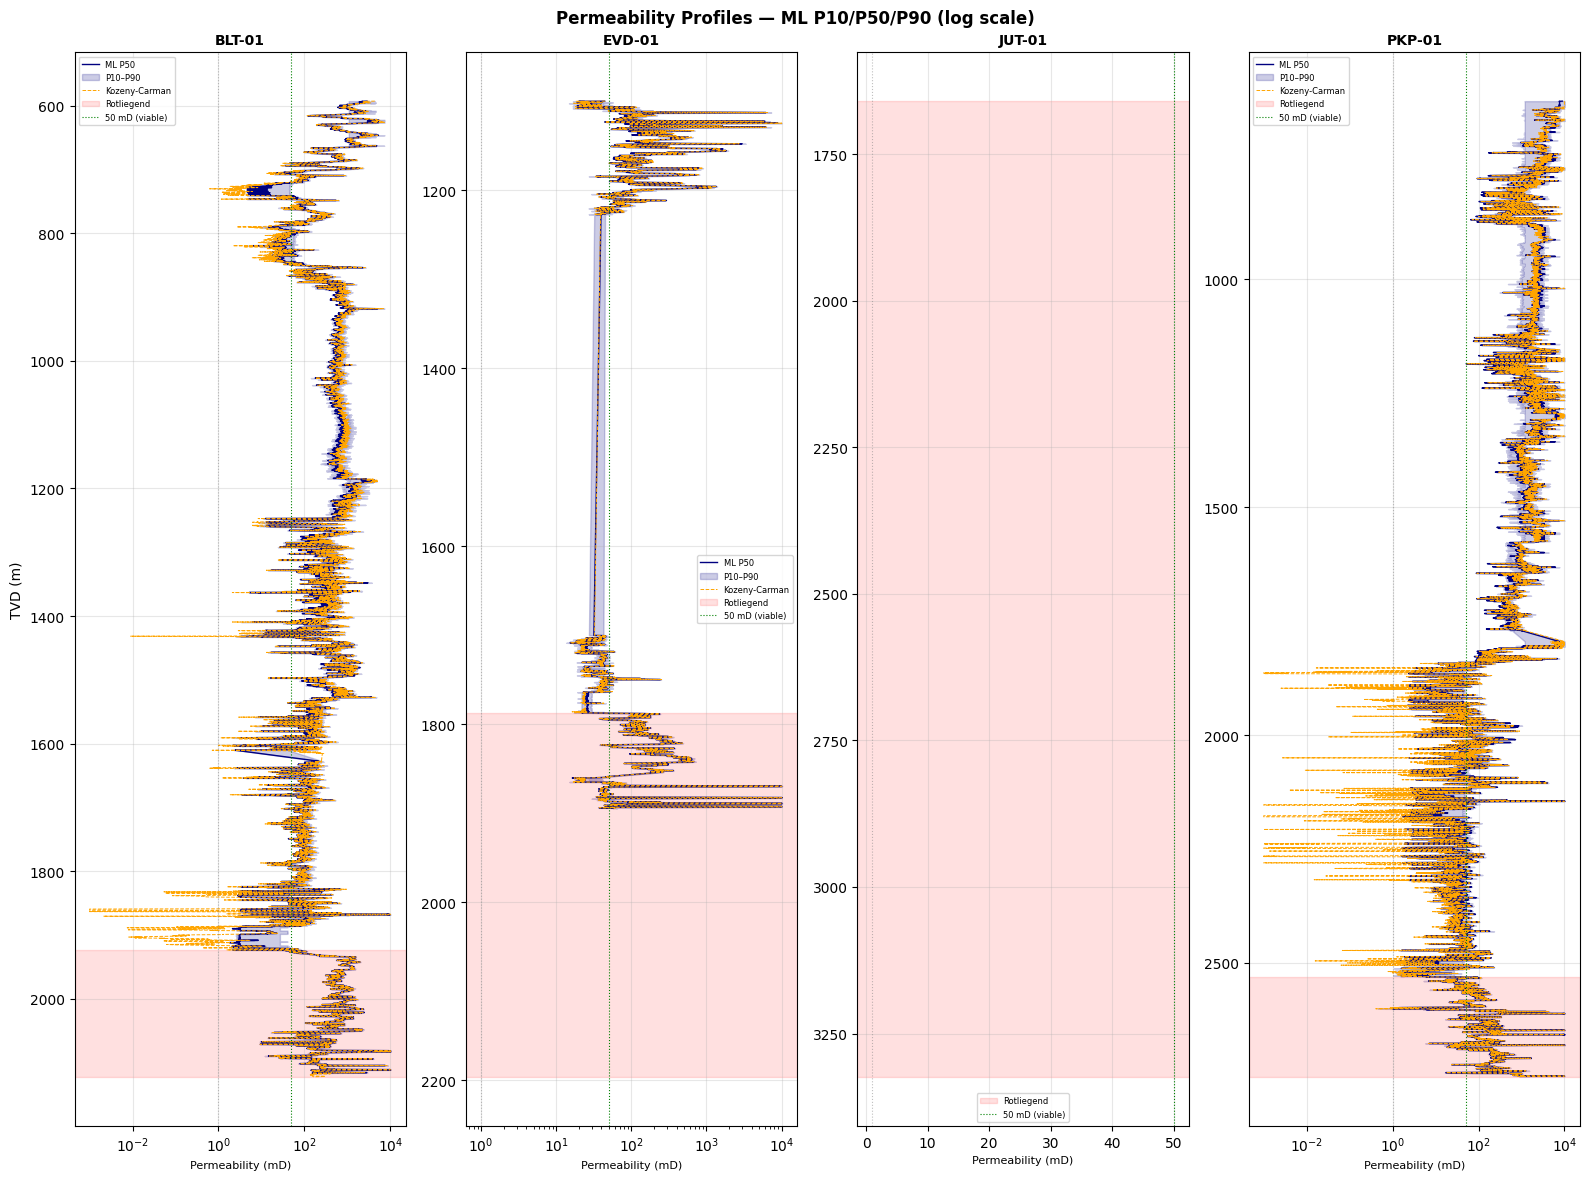

Saved: 04_permeability_profiles.png


In [7]:
fig, axes = plt.subplots(1, len(CFG["wells"]["all"]),
                         figsize=(4 * len(CFG["wells"]["all"]), 12))

for ax, well_name in zip(axes, CFG["wells"]["all"]):
    wdf = df_with_perm[df_with_perm["WELL_ID"] == well_name].sort_values("TVD_M")
    rotl_wdf = wdf[wdf["is_rotliegend"]]

    if "k_p50_md" in wdf.columns and wdf["k_p50_md"].notna().any():
        # Plot on log scale
        valid = wdf[wdf["k_p50_md"].notna() & (wdf["k_p50_md"] > 0)]
        ax.semilogx(valid["k_p50_md"], valid["TVD_M"],
                    color="navy", lw=1.0, label="ML P50")

        if "k_p10_md" in wdf.columns and "k_p90_md" in wdf.columns:
            ax.fill_betweenx(valid["TVD_M"],
                             valid["k_p10_md"].clip(lower=0.001),
                             valid["k_p90_md"].clip(lower=0.001),
                             alpha=0.2, color="navy", label="P10–P90")

    if "k_kc_md" in wdf.columns and wdf["k_kc_md"].notna().any():
        valid_kc = wdf[wdf["k_kc_md"].notna() & (wdf["k_kc_md"] > 0)]
        ax.semilogx(valid_kc["k_kc_md"], valid_kc["TVD_M"],
                    color="orange", lw=0.7, ls="--", label="Kozeny-Carman")

    # Shade Rotliegend
    if not rotl_wdf.empty:
        ax.axhspan(rotl_wdf["TVD_M"].min(), rotl_wdf["TVD_M"].max(),
                   alpha=0.12, color="red", label="Rotliegend")

    # Reference lines
    ax.axvline(50,  color="green",  lw=0.8, ls=":", label="50 mD (viable)")
    ax.axvline(1,   color="gray",   lw=0.8, ls=":", alpha=0.5)

    ax.invert_yaxis()
    ax.set_title(well_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Permeability (mD)", fontsize=8)
    if well_name == CFG["wells"]["all"][0]:
        ax.set_ylabel("TVD (m)")
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.suptitle("Permeability Profiles — ML P10/P50/P90 (log scale)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_permeability_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_permeability_profiles.png")


## 7. SHAP feature importance

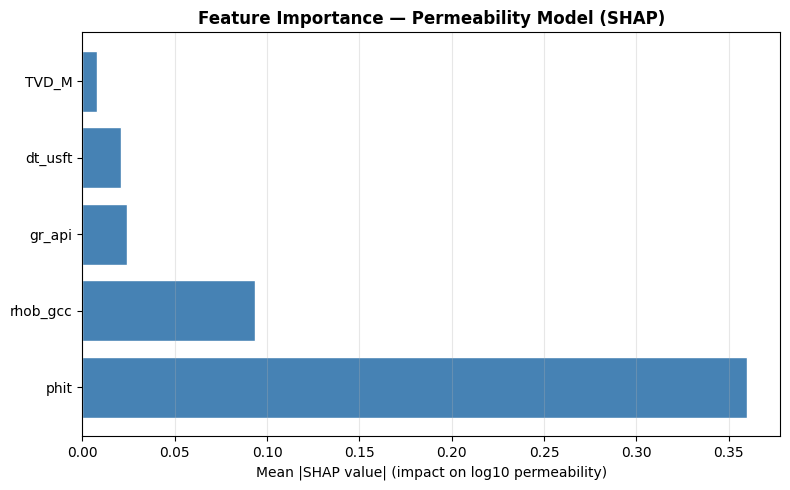

Saved: 04_shap_importance.png

SHAP values tell us which log curves drive the permeability prediction most.


In [8]:
if perm_model.shap_values is not None and perm_model.explainer is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    feature_names = perm_model.FEATURES
    mean_shap = np.abs(perm_model.shap_values).mean(axis=0)
    sorted_idx = np.argsort(mean_shap)[::-1]

    bars = ax.barh(
        [feature_names[i] for i in sorted_idx],
        [mean_shap[i] for i in sorted_idx],
        color="steelblue", edgecolor="white"
    )
    ax.set_xlabel("Mean |SHAP value| (impact on log10 permeability)", fontsize=10)
    ax.set_title("Feature Importance — Permeability Model (SHAP)", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "04_shap_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: 04_shap_importance.png")
    print("\nSHAP values tell us which log curves drive the permeability prediction most.")
else:
    print("SHAP values not available — model may not have been fitted yet.")


## 8. Save permeability profiles

In [9]:
out_path = PROC_DIR / "permeability_profiles.csv"
df_with_perm.to_csv(out_path, index=False)
perm_model.save(MODEL_DIR / "permeability_model.pkl")

print(f"Saved permeability profiles: {out_path}")
print(f"Saved model: {MODEL_DIR / 'permeability_model.pkl'}")
print(f"\nFinal column list:")
print([c for c in df_with_perm.columns])


PermeabilityModel saved to ..\outputs\models\permeability_model.pkl
Saved permeability profiles: ..\data\processed\permeability_profiles.csv
Saved model: ..\outputs\models\permeability_model.pkl

Final column list:
['WELL_ID', 'DEPTH_M', 'TVD_M', 'gr_api', 'rhob_gcc', 'drho_gcc', 'nphi_vv', 'dt_usft', 'dts_usft', 'rd_ohmm', 'rm_ohmm', 'rs_ohmm', 'formation', 'is_rotliegend', 'nphi_vv_imp_p10', 'nphi_vv_imp_p50', 'nphi_vv_imp_p90', 'nphi_vv_final', 'dt_usft_imp_p10', 'dt_usft_imp_p50', 'dt_usft_imp_p90', 'dt_usft_final', 'dts_usft_imp_p10', 'dts_usft_imp_p50', 'dts_usft_imp_p90', 'dts_usft_final', 'rs_ohmm_imp_p10', 'rs_ohmm_imp_p50', 'rs_ohmm_imp_p90', 'rs_ohmm_final', 'phit', 'k_p10_md', 'k_p50_md', 'k_p90_md', 'k_kc_md']
